In [1]:
import pandas as pd

# 1. Load the file
# 'comment=##' tells pandas to ignore the thousands of metadata lines at the top.
# 'sep=\t' because VCF is Tab-Separated.
vcf_file = 'clinvar.vcf' 
df = pd.read_csv(vcf_file, sep='\t', comment='#', header=None, low_memory=False)

# 2. Rename the standard VCF columns
df.columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']

# 3. The "Regex" Extraction
# This looks into the messy 'INFO' string and pulls out exactly what we need.
print("Parsing INFO column... this may take a minute...")

df['Clinical_Significance'] = df['INFO'].str.extract(r'CLNSIG=([^;]+)')
df['Gene'] = df['INFO'].str.extract(r'GENEINFO=([^;:]+)')
df['Disease_Name'] = df['INFO'].str.extract(r'CLNDN=([^;]+)')

# 4. Drop the original 'INFO' column to save memory
df = df.drop(columns=['INFO', 'QUAL', 'FILTER', 'ID'])

# 5. Quick Clean
# Remove rows that are missing the vital information
df = df.dropna(subset=['Clinical_Significance', 'Gene', 'Disease_Name'])

print(f"Import complete! You have {len(df)} records ready for filtering.")
print(df.head())

# 1. Define the "Clean List" of DNA bases
valid_bases = ['A', 'C', 'G', 'T']

# 2. Filter both REF and ALT to ensure they only contain valid bases
# This will automatically remove the '.', 'N', and any other weird characters
balanced_df = df[
    df['REF'].isin(valid_bases) & 
    df['ALT'].isin(valid_bases)
]

valid_chroms = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22']
balanced_df = balanced_df[balanced_df['CHROM'].astype(str).isin(valid_chroms)]
print(balanced_df['CHROM'].value_counts())

# 3. Verify the fix
print("--- Final Cleaning Results ---")
print(balanced_df['ALT'].value_counts())
print(f"Total perfect rows left for the AI: {len(balanced_df)}")

# 1. Keep ONLY single-letter mutations (SNPs)
# This removes things like 'AG' or 'TGGTCAATCA'
df_snps = df[(df['REF'].str.len() == 1) & (df['ALT'].str.len() == 1)].copy()

# 2. Map the Clinical Significance to 0 and 1
# We create a dictionary to group the "Sick" and "Healthy" labels
label_map = {
    'Pathogenic': 1, 'Likely_pathogenic': 1, 'Pathogenic/Likely_pathogenic': 1,
    'Benign': 0, 'Likely_benign': 0, 'Benign/Likely_benign': 0
}

# Apply the mapping and remove anything that isn't in our list (like 'Uncertain')
df_snps['Target'] = df_snps['Clinical_Significance'].map(label_map)
clean_df = df_snps.dropna(subset=['Target'])

# 3. Balance the Data
# Usually, you have way more Benign than Pathogenic. We make them equal.
pathogenic = clean_df[clean_df['Target'] == 1]
benign = clean_df[clean_df['Target'] == 0].sample(len(pathogenic), random_state=42)

# This is your final 'Study Guide' for the AI
balanced_df = pd.concat([pathogenic, benign]).reset_index(drop=True)

print(f"Cleaned! You now have {len(balanced_df)} perfectly balanced records.")
print(balanced_df['Target'].value_counts())

# 1. Separate the two groups
path_group = balanced_df[balanced_df['Target'] == 1]
benign_group = balanced_df[balanced_df['Target'] == 0]

# 2. Find the smallest size
min_size = min(len(path_group), len(benign_group))

# 3. Sample both to the exact same size
path_sampled = path_group.sample(n=min_size, random_state=42)
benign_sampled = benign_group.sample(n=min_size, random_state=42)

# 4. Stitch them back together
balanced_df = pd.concat([path_sampled, benign_sampled]).reset_index(drop=True)

# 5. Final Verification (This should work now!)
print("--- Final Balance Check ---")
print(balanced_df['Target'].value_counts())
print(f"Total training rows: {len(balanced_df)}")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ENCODE
nuc_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
balanced_df['REF_encoded'] = balanced_df['REF'].map(nuc_map)
balanced_df['ALT_encoded'] = balanced_df['ALT'].map(nuc_map)
balanced_df['CHROM_encoded'] = pd.to_numeric(balanced_df['CHROM'], errors='coerce')

from sklearn.preprocessing import LabelEncoder
balanced_df['Gene_encoded'] = LabelEncoder().fit_transform(balanced_df['Gene'])

balanced_df['Num_Diseases'] = balanced_df['Disease_Name'].str.count(r'\|') + 1
balanced_df['Disease_Unknown'] = balanced_df['Disease_Name'].str.contains(
    'not_provided|not_specified', na=False
).astype(int)

X = balanced_df[['REF_encoded', 'ALT_encoded', 'CHROM_encoded', 'POS', 
                  'Gene_encoded', 'Num_Diseases', 'Disease_Unknown']]

# X = balanced_df[['REF_encoded', 'ALT_encoded', 'CHROM_encoded', 'POS', 'Gene_encoded']]
# SPLIT
# X = balanced_df[['REF_encoded', 'ALT_encoded', 'CHROM_encoded', 'POS']]
y = balanced_df['Target'].astype(int)

X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42, stratify=y)

# SCALE
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Done!", X_train.shape, X_test.shape,y_train.shape, y_test.shape)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = XGBClassifier(n_estimators=890, random_state=42)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

Parsing INFO column... this may take a minute...
Import complete! You have 4017675 records ready for filtering.
  CHROM    POS REF ALT   Clinical_Significance   Gene          Disease_Name
0     1  66926  AG   A  Uncertain_significance  OR4F5  Retinitis_pigmentosa
1     1  69134   A   G           Likely_benign  OR4F5         not_specified
2     1  69241   C   T  Uncertain_significance  OR4F5         not_specified
3     1  69308   A   G  Uncertain_significance  OR4F5         not_specified
4     1  69314   T   G  Uncertain_significance  OR4F5         not_specified
CHROM
1     341786
2     327997
11    221875
17    221186
19    219600
3     205579
16    195265
7     183487
5     183300
12    172114
6     168314
9     167829
10    140061
4     135313
15    131258
8     128093
14    120787
22     82020
20     81816
13     71313
18     63436
21     41662
Name: count, dtype: int64
--- Final Cleaning Results ---
ALT
T    1069404
A    1063781
G     738718
C     732188
Name: count, dtype: int64
T

In [2]:
print(balanced_df['CHROM'].unique())

['6' 'X' '2' '11' '3' '1' '15' '7' '19' '22' '8' '9' '16' '13' '17' '10'
 '4' '5' '12' '20' '14' '18' '21' 'MT' 'Y' 'NT_187693.1']


In [5]:
balanced_df['CHROM'].value_counts()

CHROM
2              33783
1              28619
17             21424
X              19842
11             19644
3              17796
16             17342
7              15940
19             15928
5              15605
12             15111
9              15038
6              14876
15             13032
10             11303
8              10806
4              10391
14              9706
13              7216
22              6913
20              6578
18              5503
21              3959
MT               336
Y                 32
NT_187693.1        1
Name: count, dtype: int64

In [1]:
import pandas as pd

# 1. Load the file
# 'comment=##' tells pandas to ignore the thousands of metadata lines at the top.
# 'sep=\t' because VCF is Tab-Separated.
vcf_file = 'clinvar.vcf' 
df = pd.read_csv(vcf_file, sep='\t', comment='#', header=None, low_memory=False)

# 2. Rename the standard VCF columns
df.columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']

# 3. The "Regex" Extraction
# This looks into the messy 'INFO' string and pulls out exactly what we need.
print("Parsing INFO column... this may take a minute...")

df['Clinical_Significance'] = df['INFO'].str.extract(r'CLNSIG=([^;]+)')
df['Gene'] = df['INFO'].str.extract(r'GENEINFO=([^;:]+)')
df['Disease_Name'] = df['INFO'].str.extract(r'CLNDN=([^;]+)')

# 4. Drop the original 'INFO' column to save memory
df = df.drop(columns=['INFO', 'QUAL', 'FILTER', 'ID'])

# 5. Quick Clean
# Remove rows that are missing the vital information
df = df.dropna(subset=['Clinical_Significance', 'Gene', 'Disease_Name'])

print(f"Import complete! You have {len(df)} records ready for filtering.")
print(df.head())

Parsing INFO column... this may take a minute...
Import complete! You have 4017675 records ready for filtering.
  CHROM    POS REF ALT   Clinical_Significance   Gene          Disease_Name
0     1  66926  AG   A  Uncertain_significance  OR4F5  Retinitis_pigmentosa
1     1  69134   A   G           Likely_benign  OR4F5         not_specified
2     1  69241   C   T  Uncertain_significance  OR4F5         not_specified
3     1  69308   A   G  Uncertain_significance  OR4F5         not_specified
4     1  69314   T   G  Uncertain_significance  OR4F5         not_specified


In [2]:
# 1. Define the "Clean List" of DNA bases
valid_bases = ['A', 'C', 'G', 'T']

# 2. Filter both REF and ALT to ensure they only contain valid bases
# This will automatically remove the '.', 'N', and any other weird characters
balanced_df = df[
    df['REF'].isin(valid_bases) & 
    df['ALT'].isin(valid_bases)
]

valid_chroms = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22']
balanced_df = balanced_df[balanced_df['CHROM'].astype(str).isin(valid_chroms)]
print(balanced_df['CHROM'].value_counts())

# 3. Verify the fix
print("--- Final Cleaning Results ---")
print(balanced_df['ALT'].value_counts())
print(f"Total perfect rows left for the AI: {len(balanced_df)}")

CHROM
1     341786
2     327997
11    221875
17    221186
19    219600
3     205579
16    195265
7     183487
5     183300
12    172114
6     168314
9     167829
10    140061
4     135313
15    131258
8     128093
14    120787
22     82020
20     81816
13     71313
18     63436
21     41662
Name: count, dtype: int64
--- Final Cleaning Results ---
ALT
T    1069404
A    1063781
G     738718
C     732188
Name: count, dtype: int64
Total perfect rows left for the AI: 3604091


In [3]:
# 1. Keep ONLY single-letter mutations (SNPs)
# This removes things like 'AG' or 'TGGTCAATCA'
df_snps = df[(df['REF'].str.len() == 1) & (df['ALT'].str.len() == 1)].copy()

# 2. Map the Clinical Significance to 0 and 1
# We create a dictionary to group the "Sick" and "Healthy" labels
label_map = {
    'Pathogenic': 1, 'Likely_pathogenic': 1, 'Pathogenic/Likely_pathogenic': 1,
    'Benign': 0, 'Likely_benign': 0, 'Benign/Likely_benign': 0
}

# Apply the mapping and remove anything that isn't in our list (like 'Uncertain')
df_snps['Target'] = df_snps['Clinical_Significance'].map(label_map)
clean_df = df_snps.dropna(subset=['Target'])

# 3. Balance the Data
# Usually, you have way more Benign than Pathogenic. We make them equal.
pathogenic = clean_df[clean_df['Target'] == 1]
benign = clean_df[clean_df['Target'] == 0].sample(len(pathogenic), random_state=42)

# This is your final 'Study Guide' for the AI
balanced_df = pd.concat([pathogenic, benign]).reset_index(drop=True)

print(f"Cleaned! You now have {len(balanced_df)} perfectly balanced records.")
print(balanced_df['Target'].value_counts())

Cleaned! You now have 336724 perfectly balanced records.
Target
1.0    168362
0.0    168362
Name: count, dtype: int64


In [4]:
# 1. Separate the two groups
path_group = balanced_df[balanced_df['Target'] == 1]
benign_group = balanced_df[balanced_df['Target'] == 0]

# 2. Find the smallest size
min_size = min(len(path_group), len(benign_group))

# 3. Sample both to the exact same size
path_sampled = path_group.sample(n=min_size, random_state=42)
benign_sampled = benign_group.sample(n=min_size, random_state=42)

# 4. Stitch them back together
balanced_df = pd.concat([path_sampled, benign_sampled]).reset_index(drop=True)

# 5. Final Verification (This should work now!)
print("--- Final Balance Check ---")
print(balanced_df['Target'].value_counts())
print(f"Total training rows: {len(balanced_df)}")

--- Final Balance Check ---
Target
1.0    168362
0.0    168362
Name: count, dtype: int64
Total training rows: 336724


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ENCODE
nuc_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
balanced_df['REF_encoded'] = balanced_df['REF'].map(nuc_map)
balanced_df['ALT_encoded'] = balanced_df['ALT'].map(nuc_map)

drop_chroms = ['NT_187693.1']
balanced_df = balanced_df[~balanced_df['CHROM'].astype(str).isin(drop_chroms)].reset_index(drop=True)

chrom_order = {str(i): i for i in range(1, 23)}
chrom_order['X']  = 23
chrom_order['MT'] = 24
chrom_order['Y']  = 25

balanced_df['CHROM_encoded'] = balanced_df['CHROM'].map(chrom_order)
print(balanced_df['CHROM_encoded'].isna().sum(), "← should be 0")

from sklearn.preprocessing import LabelEncoder
balanced_df['Gene_encoded'] = LabelEncoder().fit_transform(balanced_df['Gene'])

balanced_df['Num_Diseases'] = balanced_df['Disease_Name'].str.count(r'\|') + 1
balanced_df['Disease_Unknown'] = balanced_df['Disease_Name'].str.contains(
    'not_provided|not_specified', na=False
).astype(int)

0 ← should be 0


In [6]:
X = balanced_df[['REF_encoded', 'ALT_encoded', 'CHROM_encoded', 'POS', 
                  'Gene_encoded', 'Num_Diseases', 'Disease_Unknown']]

# X = balanced_df[['REF_encoded', 'ALT_encoded', 'CHROM_encoded', 'POS', 'Gene_encoded']]
# SPLIT
# X = balanced_df[['REF_encoded', 'ALT_encoded', 'CHROM_encoded', 'POS']]
y = balanced_df['Target'].astype(int)

X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42, stratify=y)

# SCALE
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Done!", X_train.shape, X_test.shape,y_train.shape, y_test.shape)

Done! (333217, 7) (3366, 7) (333217,) (3366,)


In [7]:
balanced_df

,CHROM,POS,REF,ALT,Clinical_Significance,Gene,Disease_Name,Target,REF_encoded,ALT_encoded,CHROM_encoded,Gene_encoded,Num_Diseases,Disease_Unknown
0,6,30916245,G,T,Pathogenic,VARS2,Combined_oxidative_phosphorylation_defect_type_20,1.0,2,3.0,6,10554,1,0
1,X,154947768,C,G,Pathogenic,F8,Hereditary_factor_IX_deficiency_disease,1.0,1,2.0,23,3146,1,0
2,2,46905540,C,T,Likely_pathogenic,MCFD2,Thrombocytopenia|Abnormal_bleeding,1.0,1,3.0,2,5598,2,0
3,2,178572398,C,T,Likely_pathogenic,TTN,Cardiovascular_phenotype|Dilated_cardiomyopath...,1.0,1,3.0,2,10297,3,0
4,11,17501481,C,A,Likely_pathogenic,USH1C,not_provided,1.0,1,0.0,11,10486,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336718,2,71480871,T,C,Likely_benign,DYSF,Neuromuscular_disease_caused_by_qualitative_or...,0.0,3,1.0,2,2818,1,0
336719,X,74531188,C,G,Benign,SLC16A2,not_provided,0.0,1,2.0,23,8781,1,1
336720,7,152171274,G,A,Likely_benign,KMT2C,not_provided,0.0,2,0.0,7,5017,1,1
336721,14,73186909,C,T,Likely_benign,PSEN1,Pick_disease|Frontotemporal_dementia|Acne_inve...,0.0,1,3.0,14,7703,5,1


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = XGBClassifier(n_estimators=890, random_state=42)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      1683
           1       0.77      0.78      0.77      1683

    accuracy                           0.77      3366
   macro avg       0.77      0.77      0.77      3366
weighted avg       0.77      0.77      0.77      3366



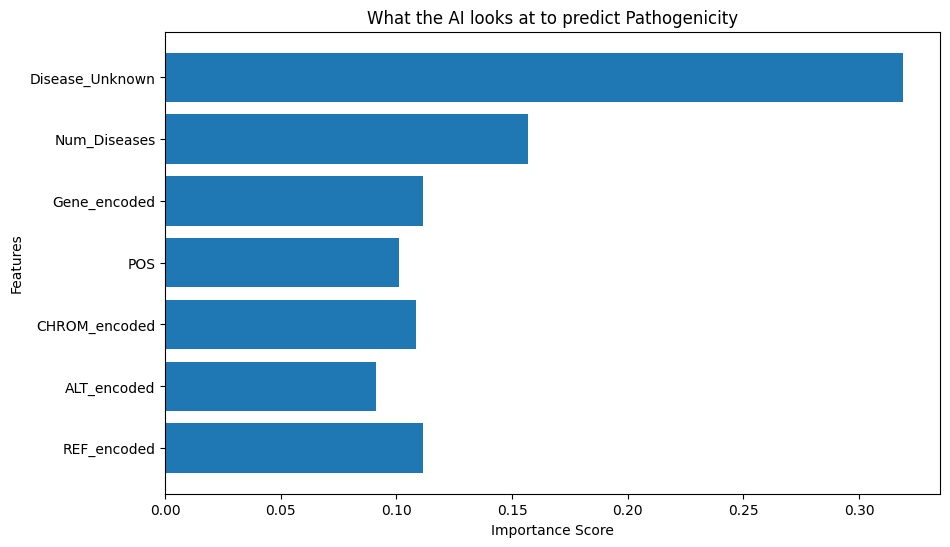

In [9]:
import matplotlib.pyplot as plt

# Get feature importance
importances = model.feature_importances_
feature_names = X.columns

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("What the AI looks at to predict Pathogenicity")
plt.show()

Reasons for higher significance:
natural coincidence of correlation between disease unkown and target, because it isnt a perfect 50 percent split of disease unkown and disease known and the target
natural correlation between disease unkown and other features


In [ ]:
# ── FIXED: Save cell for main.ipynb ──────────────────────────────────────────
# Replace the existing joblib.dump / lookup_table save block with this.

import joblib

# 1. Save the model
joblib.dump(model, 'xgboost_dna_model.pkl')

# 2. Save the nucleotide map
joblib.dump(nuc_map, 'nuc_map.pkl')

# 3. Save the scaler  ← app.py needs this to match training-time scaling
joblib.dump(scaler, 'scaler.pkl')
# 4. Save chrom_order  ← app.py needs this; DO NOT use nuc_map for chromosomes
joblib.dump(chrom_order, 'chrom_order.pkl')

# 5. Save the disease lookup — NOW includes Gene_encoded so the app can use it
lookup_table = (
    balanced_df[['CHROM_encoded', 'POS', 'Gene', 'Gene_encoded',
                 'Disease_Name', 'Num_Diseases', 'Disease_Unknown']]
    .drop_duplicates(subset=['CHROM_encoded', 'POS'])
)
lookup_table.to_csv('disease_lookup.csv', index=False)

print("All 5 files saved successfully!")
print(f"  disease_lookup.csv  → {len(lookup_table):,} rows")
print(f"  chrom_order keys    → {sorted(chrom_order.keys())}")

All 5 files saved successfully!
  disease_lookup.csv  → 317,523 rows
  chrom_order keys    → ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9', 'MT', 'X', 'Y']


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70      1616
           1       0.69      0.69      0.69      1548

    accuracy                           0.70      3164
   macro avg       0.69      0.69      0.69      3164
weighted avg       0.70      0.70      0.70      3164



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.71      0.40      0.51      1616
           1       0.57      0.83      0.68      1548

    accuracy                           0.61      3164
   macro avg       0.64      0.62      0.60      3164
weighted avg       0.64      0.61      0.59      3164



In [30]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.70      0.60      0.64      1616
           1       0.63      0.73      0.68      1548

    accuracy                           0.66      3164
   macro avg       0.67      0.66      0.66      3164
weighted avg       0.67      0.66      0.66      3164



In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

results = []
for n in range(1, 20):
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append((n, acc))
    print(f"n_estimators={n}, accuracy={acc:.4f}")

n_estimators=1, accuracy=0.6719
n_estimators=2, accuracy=0.6776
n_estimators=3, accuracy=0.6896
n_estimators=4, accuracy=0.6918
n_estimators=5, accuracy=0.6991
n_estimators=6, accuracy=0.6985
n_estimators=7, accuracy=0.6963
n_estimators=8, accuracy=0.6950
n_estimators=9, accuracy=0.6956
n_estimators=10, accuracy=0.6950
n_estimators=11, accuracy=0.6944
n_estimators=12, accuracy=0.6988
n_estimators=13, accuracy=0.6969
n_estimators=14, accuracy=0.6969
n_estimators=15, accuracy=0.6944
n_estimators=16, accuracy=0.6931
n_estimators=17, accuracy=0.6937
n_estimators=18, accuracy=0.6963
n_estimators=19, accuracy=0.6979


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

results = []
for n in range(10, 210, 10):
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append((n, acc))
    print(f"n_estimators={n}, accuracy={acc:.4f}")

n_estimators=10, accuracy=0.6950
n_estimators=20, accuracy=0.6969
n_estimators=30, accuracy=0.6944
n_estimators=40, accuracy=0.6956
n_estimators=50, accuracy=0.6937
n_estimators=60, accuracy=0.6931
n_estimators=70, accuracy=0.6918
n_estimators=80, accuracy=0.6893


KeyboardInterrupt: 

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

results = []
for n in range(10, 201, 10):
    model = GradientBoostingClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append((n, acc))
    print(f"n_estimators={n}, accuracy={acc:.4f}")

n_estimators=10, accuracy=0.6122
n_estimators=20, accuracy=0.6147
n_estimators=30, accuracy=0.6150
n_estimators=40, accuracy=0.6438
n_estimators=50, accuracy=0.6460


KeyboardInterrupt: 

In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

results = []
for n in range(10, 5010, 100):
    model = XGBClassifier(n_estimators=n, random_state=42, n_jobs=-1, eval_metric='logloss')
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append((n, acc))
    print(f"n_estimators={n}, accuracy={acc:.4f}")

n_estimators=10, accuracy=0.6621
n_estimators=110, accuracy=0.7260
n_estimators=210, accuracy=0.7358


KeyboardInterrupt: 

In [40]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

results = []
for n in range(10, 201, 10):
    print("Random_State:", n)
    for m in range(1, 100, 10):
        model = GradientBoostingClassifier(n_estimators=m, random_state=n)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append((n, acc))
        print(f"n_estimators={n}, accuracy={acc:.4f}")

Random_State: 10
n_estimators=10, accuracy=0.5320
n_estimators=10, accuracy=0.5753
n_estimators=10, accuracy=0.5917
n_estimators=10, accuracy=0.5950
n_estimators=10, accuracy=0.6056
n_estimators=10, accuracy=0.6008
n_estimators=10, accuracy=0.6043
n_estimators=10, accuracy=0.6072
n_estimators=10, accuracy=0.6143
n_estimators=10, accuracy=0.6192
Random_State: 20
n_estimators=20, accuracy=0.5320
n_estimators=20, accuracy=0.5753
n_estimators=20, accuracy=0.5917
n_estimators=20, accuracy=0.5950


KeyboardInterrupt: 

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

results = []
for n in range(1, 100):
    print("Random_state:", n)
    for m in range(10, 1010, 100):
        model = XGBClassifier(n_estimators=m, random_state=n, n_jobs=-1, eval_metric='logloss')
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append((m, acc))
        print(f"n_estimators={m}, accuracy={acc:.4f}")

Random_state: 1
n_estimators=10, accuracy=0.6156
n_estimators=110, accuracy=0.6560
n_estimators=210, accuracy=0.6576
n_estimators=310, accuracy=0.6654
n_estimators=410, accuracy=0.6647
n_estimators=510, accuracy=0.6676
n_estimators=610, accuracy=0.6654
n_estimators=710, accuracy=0.6680
n_estimators=810, accuracy=0.6686
n_estimators=910, accuracy=0.6676
Random_state: 2
n_estimators=10, accuracy=0.6156
n_estimators=110, accuracy=0.6560
n_estimators=210, accuracy=0.6576
n_estimators=310, accuracy=0.6654
n_estimators=410, accuracy=0.6647
n_estimators=510, accuracy=0.6676
n_estimators=610, accuracy=0.6654
n_estimators=710, accuracy=0.6680
n_estimators=810, accuracy=0.6686
n_estimators=910, accuracy=0.6676
Random_state: 3
n_estimators=10, accuracy=0.6156
n_estimators=110, accuracy=0.6560
n_estimators=210, accuracy=0.6576
n_estimators=310, accuracy=0.6654


KeyboardInterrupt: 

In [5]:
print(f"Cleaned! You now have {len(balanced_df)} perfectly balanced records.")
print(balanced_df['Target'].value_counts())

Cleaned! You now have 336496 perfectly balanced records.
Target
1.0    168248
0.0    168248
Name: count, dtype: int64


In [15]:
balanced_df[['ALT', 'POS']].to_csv("test.csv", sep='\t')